<a href="https://colab.research.google.com/github/angelaalexo/VNP-labs/blob/master/Copy_of_Laboratory_exercise_2_Introduction_to_Data_Science_(17_11_2023).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction
For today's laboratory exercise, we will work with the data available at https://skopje.pulse.eco/ For that you will first need to register on the site with your user and password, registration site: https://skopje.pulse.eco/register
The documantation for sending request to the API is given here: https://martinkozle.github.io/pulse-eco/example-usage/

# Requirements

In [ ]:
import pandas as pd
import missingno as msno
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
!python -m pip install pulse-eco


In [ ]:
from pulseeco import PulseEcoClient

#change the user and pass with your own
pulse_eco = PulseEcoClient(city_name="skopje", auth=("angelaaleksovska", "angela123"))

# Laboratory Exercise - Run Mode (8 points)

##Dataset creation

Now you need to extract the avg_data per month from 1.3.2019 till 1.5.2023 for PM10,PM2.5 and temperature. (see function avg_data from the documantation)

In [ ]:
import datetime
>>> from pulseeco import AveragePeriod, DataValueType
>>> pulse_eco.avg_data(
...   period=AveragePeriod.MONTH,
...   from_=datetime.datetime(year=2019, month=3, day=1, hour=12),
...   to=datetime.datetime(year=2023, month=5, day=1, hour=12),
...   type=DataValueType.PM10,
...   sensor_id="-1",
... )

[DataValue(sensor_id='-1', stamp=datetime.datetime(2019, 3, 1, 13, 0, tzinfo=TzInfo(+01:00)), type='pm10', position='', value=29, year=None),
 DataValue(sensor_id='-1', stamp=datetime.datetime(2019, 4, 1, 14, 0, tzinfo=TzInfo(+02:00)), type='pm10', position='', value=19, year=None),
 DataValue(sensor_id='-1', stamp=datetime.datetime(2019, 5, 1, 14, 0, tzinfo=TzInfo(+02:00)), type='pm10', position='', value=12, year=None),
 DataValue(sensor_id='-1', stamp=datetime.datetime(2019, 6, 1, 14, 0, tzinfo=TzInfo(+02:00)), type='pm10', position='', value=15, year=None),
 DataValue(sensor_id='-1', stamp=datetime.datetime(2019, 7, 1, 14, 0, tzinfo=TzInfo(+02:00)), type='pm10', position='', value=13, year=None),
 DataValue(sensor_id='-1', stamp=datetime.datetime(2019, 8, 1, 14, 0, tzinfo=TzInfo(+02:00)), type='pm10', position='', value=16, year=None),
 DataValue(sensor_id='-1', stamp=datetime.datetime(2019, 9, 1, 14, 0, tzinfo=TzInfo(+02:00)), type='pm10', position='', value=18, year=None),
 DataV

In [ ]:
import datetime
from pulseeco import  AveragePeriod, DataValueType

start_date = datetime.datetime(year=2019, month=3, day=1, hour=12)
end_date = datetime.datetime(year=2023, month=5, day=1, hour=12)

pm10_data = pulse_eco.avg_data(period=AveragePeriod.MONTH, from_=start_date, to=end_date, type=DataValueType.PM10, sensor_id="-1")
pm25_data = pulse_eco.avg_data(period=AveragePeriod.MONTH, from_=start_date, to=end_date, type=DataValueType.PM25, sensor_id="-1")
temperature_data = pulse_eco.avg_data(period=AveragePeriod.MONTH, from_=start_date, to=end_date, type=DataValueType.TEMPERATURE, sensor_id="-1")
avg_data = pulse_eco.avg_data(period=AveragePeriod.MONTH, from_=start_date, to=end_date, type=DataValueType.PM10, sensor_id="-1")

pm10_values = [entry.value for entry in pm10_data]
print("PM10 Values:", pm10_values)

pm25_values = [entry.value for entry in pm25_data]
print("PM2.5 Values:", pm25_values)

temperature_values = [entry.value for entry in temperature_data]
print("Temperature values:",temperature_values)

date_list = [entry.stamp.replace(tzinfo=None) for entry in avg_data]
date_strings = [entry.strftime("%d.%m.%Y") for entry in date_list]
print("Date values:",date_strings)

PM10 Values: [29, 19, 12, 15, 13, 16, 18, 33, 33, 54, 89, 43, 29, 17, 12, 10, 14, 17, 13, 25, 79, 66, 49, 59, 30, 17, 12, 18, 17, 17, 15, 26, 44, 52, 56, 40, 32, 18, 15, 13, 11, 12, 25, 55, 85, 64, 48, 13, 12]
PM2.5 Values: [19, 12, 8, 9, 8, 10, 12, 21, 21, 33, 51, 25, 18, 10, 7, 6, 15, 11, 9, 16, 50, 40, 31, 38, 20, 10, 6, 10, 10, 10, 9, 18, 30, 35, 37, 26, 21, 11, 9, 8, 7, 7, 15, 34, 51, 37, 29, 8, 7]
Temperature values: [15, 18, 20, 27, 28, 30, 24, 20, 15, 8, 6, 9, 12, 16, 21, 24, 28, 27, 25, 18, 11, 9, 7, 9, 10, 14, 21, 25, 29, 29, 23, 14, 12, 7, 5, 8, 9, 15, 22, 27, 28, 27, 17, 13, 9, 8, 8, 14, 19]
Date values: ['01.03.2019', '01.04.2019', '01.05.2019', '01.06.2019', '01.07.2019', '01.08.2019', '01.09.2019', '01.10.2019', '01.11.2019', '01.12.2019', '01.01.2020', '01.02.2020', '01.03.2020', '01.04.2020', '01.05.2020', '01.06.2020', '01.07.2020', '01.08.2020', '01.09.2020', '01.10.2020', '01.11.2020', '01.12.2020', '01.01.2021', '01.02.2021', '01.03.2021', '01.04.2021', '01.05.2021

Make a dataframe containing the following
columns: date,pm10,pm2.5,temperature.

In [ ]:
dict_ = {
    'Date': date_strings,
    'PM10': pm10_values,
    'PM2.5': pm25_values,
    'Temperature': temperature_values,
}

Load the dataset into a `pandas` data frame.

In [ ]:
df = pd.DataFrame(dict_)
df

,Date,PM10,PM2.5,Temperature
0,01.03.2019,29,19,15
1,01.04.2019,19,12,18
2,01.05.2019,12,8,20
3,01.06.2019,15,9,27
4,01.07.2019,13,8,28
5,01.08.2019,16,10,30
6,01.09.2019,18,12,24
7,01.10.2019,33,21,20
8,01.11.2019,33,21,15
9,01.12.2019,54,33,8


Drop the column `pm10` as it shouldn't be used for prediction.

In [ ]:
df = df.drop(columns=['PM10'])
print(df)

          Date  PM2.5  Temperature
0   01.03.2019     19           15
1   01.04.2019     12           18
2   01.05.2019      8           20
3   01.06.2019      9           27
4   01.07.2019      8           28
5   01.08.2019     10           30
6   01.09.2019     12           24
7   01.10.2019     21           20
8   01.11.2019     21           15
9   01.12.2019     33            8
10  01.01.2020     51            6
11  01.02.2020     25            9
12  01.03.2020     18           12
13  01.04.2020     10           16
14  01.05.2020      7           21
15  01.06.2020      6           24
16  01.07.2020     15           28
17  01.08.2020     11           27
18  01.09.2020      9           25
19  01.10.2020     16           18
20  01.11.2020     50           11
21  01.12.2020     40            9
22  01.01.2021     31            7
23  01.02.2021     38            9
24  01.03.2021     20           10
25  01.04.2021     10           14
26  01.05.2021      6           21
27  01.06.2021     1

Explore the dataset using visualizations of your choice.

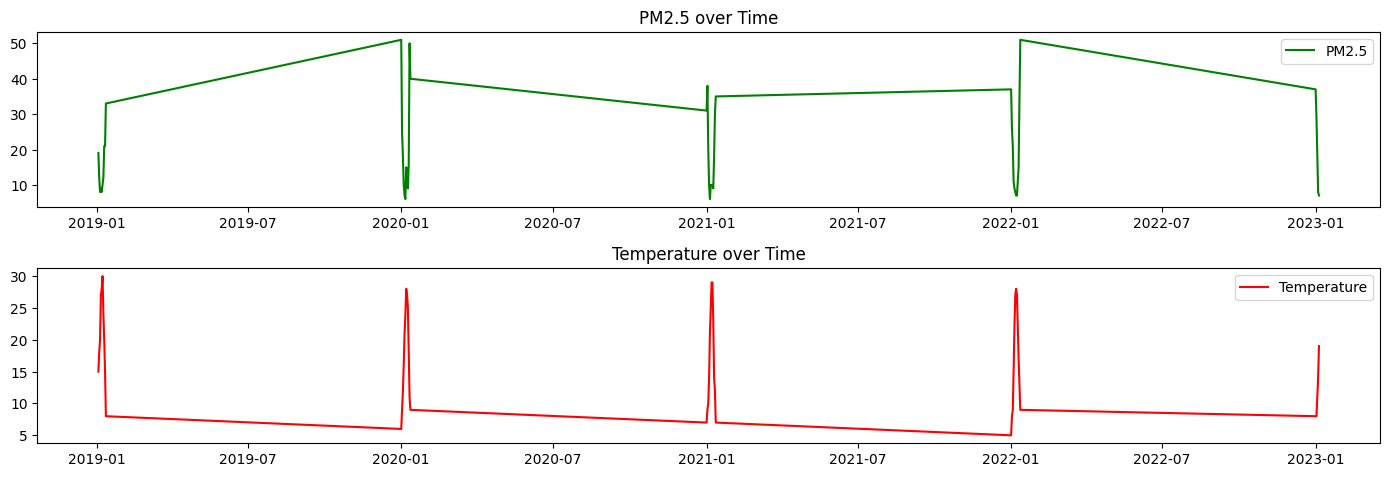

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Date']=pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

plt.figure(figsize=(14,7))

plt.subplot(3, 1, 1)
plt.plot(df['PM2.5'], label='PM2.5', color='green')
plt.title('PM2.5 over Time')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(df['Temperature'], label='Temperature', color='red')
plt.title('Temperature over Time')
plt.legend()

plt.tight_layout()
plt.show()

Make visualization of the target column

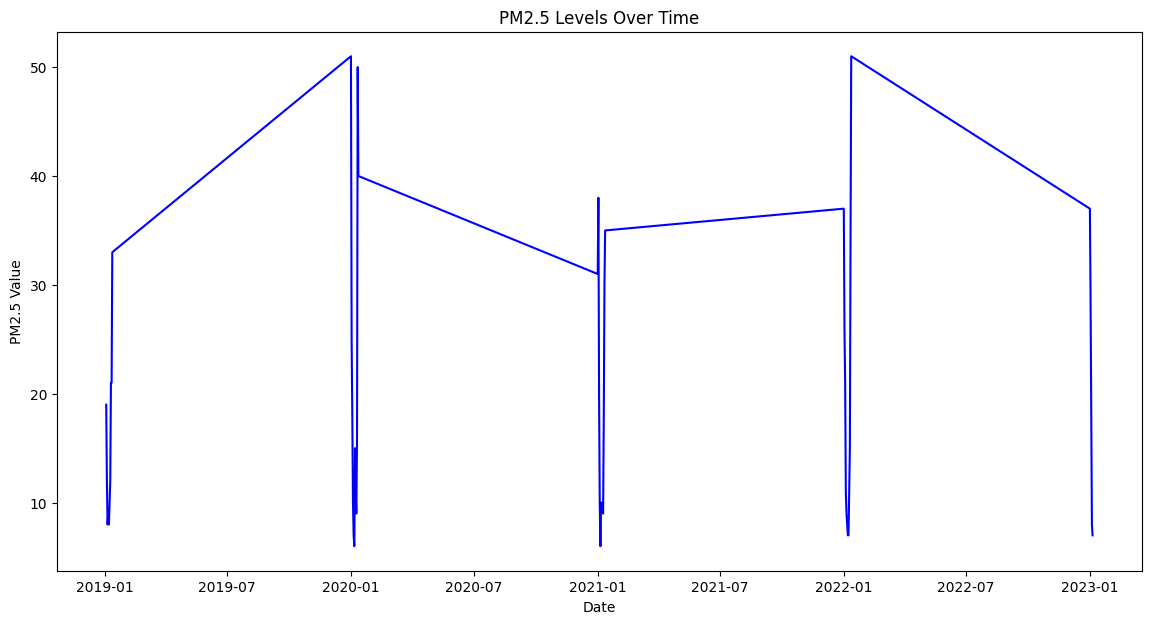

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(x=df.index, y='PM2.5', data=df, color='blue')
plt.title('PM2.5 Levels Over Time')
plt.xlabel('Date')
plt.ylabel('PM2.5 Value')
plt.show()

##Data splitting
split the data on training and testing in ratio 80:20

In [ ]:
from sklearn.model_selection import train_test_split

X=df['Temperature']
y=df['PM2.5']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (39,)
X_test shape: (10,)
y_train shape: (39,)
y_test shape: (10,)


## Feature Scaling
Standardize the features using `StandardScaler`.

In [ ]:
from sklearn.preprocessing import StandardScaler

X_train_reshaped = X_train.values.reshape(-1, 1)
X_test_reshaped = X_test.values.reshape(-1, 1)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.fit_transform(X_test_reshaped)

## Linear regression

Create an instance of the Linear regression model and train it using the `fit` function.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_scaled, y_train)

LinearRegression()

Use the trained model to make predictions for the test set.

In [ ]:
y_pred = model.predict(X_test_scaled)

Assess the performance of the model by using different classification metrics provided by the `scikit-learn` library.

In [ ]:
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
print(mae)

7.246009989485634


# Laboratory Exercise - Bonus Task (+ 2 points)

Make a kfold split using cross validation on the training dataset with `k=5`


